In [2]:
import mne
from mne.preprocessing import ICA, create_eog_epochs, compute_proj_eog
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
from scipy.signal import detrend
from collections import OrderedDict
import matplotlib.pyplot as plt
import re
#import warnings
#!pip install python-picard
#!pip install eeglabio
#clear_output()
#warninings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
DIRECTORY = "/Users/jowanglin/Word-Position-Effect_BLP-lab/Preprocessing/ica-data"
RAW_FILE_PATH = "SUBJ020/subj020.set"
EPOCHS_FILE_PATH = "SUBJ020/subj020_chan_rr_elist_bin_epbaseline_AD_BPdot1-30.set"

NOISE_COV = None                      # Noise covariance used for pre-whitening. If None (default), channels are scaled to unit variance (“z-standardized”) as a group by channel type prior to the whitening by PCA.
RANDOM_STATE = 42                     # Fix this throughout the script -- always!!

METHOD = "infomax"                    # MNE accepts 'fastica' | 'infomax' | 'picard'; using "picard" to match EEGLAB default -> need to pip install python-picard

FIT_PARAMS={"extended": True,         # EEGLAB default is infomax extended
            "weights": None,          # The initialized unmixing matrix. Defaults to None, which means the identity matrix is used.
            "l_rate": None,           # This quantity indicates the relative size of the change in weights. Defaults to 0.01 / log(n_features ** 2).
            "block": None,            # The block size of randomly chosen data segments. Defaults to floor(sqrt(n_times / 3.)).           
            "w_change": 1e-12,        # The change at which to stop iteration. Defaults to 1e-12.
            "anneal_deg": 60.0,       # The angle (in degrees) at which the learning rate will be reduced. Defaults to 60.0.
            "anneal_step": 0.9,        # The factor by which the learning rate will be reduced. Defaults to 0.9.
            "n_subgauss": 1,          # The number of subgaussian components. Only considered for extended Infomax. Defaults to 1.
            "kurt_size": 6000,        # The window size for kurtosis estimation. Only considered for extended Infomax. Defaults to 6000.
            "blowup": 10000}          # The maximum difference allowed between two successive estimations of the unmixing matrix. Defaults to 10000.

# for picard
#FIT_PARAMS={"tol": 1e-7,
            #"ortho": False, # If True, uses Picard-O. Otherwise, uses the standard Picard.
            #"fastica_it": None} # If an int, perform fastica_it iterations of FastICA before running Picard. It might help starting from a better point.


MAX_ITER=1000 
#allow_ref_meg -> irrelevant
VERBOSE=True # verbose output

In [7]:
def delete_time_segments(raw, time_threshold=3, after_event_code_buffer=1.5, before_event_code_buffer=0.5):
    annot = raw.annotations
    diffs = np.diff(annot.onset)
    ends, starts = [int(i) for i in np.where(diffs > 3)[0]], [int(j)+1 for j in np.where(diffs > time_threshold)[0]]
    afterEventcodeBuffers = [OrderedDict({"onset": annot.onset[i]+after_event_code_buffer,
                                        "duration": 0,
                                        "description": "bad (afterEventcodeBuffer)"})
                                        for i in ends]
    beforeEventcodeBuffers = [OrderedDict({"onset": annot.onset[i]-before_event_code_buffer,
                                          "duration": 0,
                                          "description": "(beforeEventcodeBuffer)"})
                                        for i in starts]
    concat_annot_list = list(annot) + afterEventcodeBuffers + beforeEventcodeBuffers
    concat_annot_list.sort(key=lambda x: x["onset"])
    concat_annot = mne.Annotations(onset=[item["onset"] for item in concat_annot_list],
                                duration=np.diff(np.array([item["onset"]
                                                           for item in concat_annot_list] + [raw.times[-1]+1])),  # duration is the time until the next annotation, except for the last one which is until the end of the recording
                                description=[item["description"] for item in concat_annot_list])
    raw.set_annotations(concat_annot)
    
    data_del = raw.get_data(reject_by_annotation="omit")
    return raw, data_del

### Data Preprocessing Steps in Common:

- Loading dataset
- Adding channel montage
- Setting event annotations
- Re-referencing

In [17]:
# Load dataset
raw_orig = mne.io.read_raw_eeglab(f"{DIRECTORY}/{RAW_FILE_PATH}")

# Setting a built-in montage (i.e., adding channel locations) 
ch_names = raw_orig.ch_names
ch_types = ["eeg" if i not in ["HEO","VEO"] else "eog" for i in ch_names]
info = mne.create_info(ch_names, ch_types=ch_types, sfreq=raw_orig.info["sfreq"])
info.set_montage("standard_1005", on_missing="raise")
raw = mne.io.RawArray(data=raw_orig.get_data(), info=info)
montage = raw.get_montage();
assert len(montage.ch_names) == len(raw_orig.ch_names) 

raw = raw.set_annotations(raw_orig.annotations)
boundaries = [item for item in raw.annotations if item["description"] == "boundary"]
print(f">> Found {len(boundaries)} boundary event(s) in the raw dataset:")
print(boundaries)

# Re-referencing
zero_raw = mne.io.RawArray(data=np.zeros((1, raw.n_times)),
                           info=mne.create_info(["ghost"], sfreq=raw.info["sfreq"], ch_types=["eeg"]))
raw.add_channels([zero_raw], force_update_info=False)
assert np.array_equal(raw.get_data()[[raw.ch_names.index("ghost")], :], np.zeros((1, raw.n_times)))  

REREF_DICT = {ch: ["TP10", "ghost"] for ch in raw.ch_names}
mne.set_eeg_reference(raw, ref_channels=REREF_DICT, ch_type='eeg', copy=False) 
raw.drop_channels(["ghost"], on_missing="raise") # drop the ghost channel after re-referencing
assert raw.ch_names == raw_orig.ch_names

Reading /Users/jowanglin/Word-Position-Effect_BLP-lab/Preprocessing/ica-data/SUBJ020/subj020.fdt


/var/folders/n3/nqqvqq1n0jx25dfd3nyxjxmh0000gn/T/ipykernel_63764/806806292.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_orig = mne.io.read_raw_eeglab(f"{DIRECTORY}/{RAW_FILE_PATH}")


Creating RawArray with float64 data, n_channels=31, n_times=3290100
    Range : 0 ... 3290099 =      0.000 ...  3290.099 secs
Ready.
>> Found 1 boundary event(s) in the raw dataset:
[OrderedDict([('onset', np.float64(0.0)), ('duration', np.float64(0.0)), ('description', np.str_('boundary')), ('orig_time', None), ('extras', {})])]
Creating RawArray with float64 data, n_channels=1, n_times=3290100
    Range : 0 ... 3290099 =      0.000 ...  3290.099 secs
Ready.
Applying a custom dict-based reference.


### ICA
Filter settings:
- Highpass 0.1 Hz, 2nd order IIR Butterworth
- Bandpass 1 - 30 Hz, 8th order IIR Butterworth

In [18]:
# Detrend data (remove DC offset)
raw_usual = raw.copy()
data = raw.copy().get_data()
data_detrended = detrend(data, axis=-1, type="constant")
raw = mne.io.RawArray(data=data_detrended, info=info)
_ = raw.set_annotations(raw_usual.annotations)

# Bandpass
bandpass_params_for_ica = mne.filter.create_filter(
    data=raw.get_data(),
    sfreq=raw.info["sfreq"],
    l_freq=1, h_freq=30,  
    method="iir",
    iir_params={"order": 8, "ftype": "butter"},
    verbose=True
)

bandpass_params_usual = mne.filter.create_filter(
    data=raw.get_data(),
    sfreq=raw.info["sfreq"],
    l_freq=0.1, h_freq=30,  
    method="iir",
    iir_params={"order": 2, "ftype": "butter"},
    verbose=True
)

raw_for_ica = raw.copy().filter(l_freq=1, h_freq=30, method="iir", iir_params=bandpass_params_for_ica, verbose=False)

Creating RawArray with float64 data, n_channels=31, n_times=3290100
    Range : 0 ... 3290099 =      0.000 ...  3290.099 secs
Ready.
Setting up band-pass filter from 1 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 32 (effective, after forward-backward)
- Cutoffs at 1.00, 30.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 0.1 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoffs at 0.10, 30.00 Hz: -6.02, -6.02 dB



In [8]:
raw_for_ica_copy = raw_for_ica.copy()
raw_for_ica, data_del = delete_time_segments(raw_for_ica_copy, time_threshold=3, after_event_code_buffer=1.5, before_event_code_buffer=0.5)
display(pd.DataFrame(raw_for_ica.annotations))

Omitting 948199 of 3290100 (28.82%) samples, retaining 2341901 (71.18%) samples.


/var/folders/n3/nqqvqq1n0jx25dfd3nyxjxmh0000gn/T/ipykernel_63764/2073571559.py:19: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(concat_annot)


,onset,duration,description,orig_time,extras
0,0.000,1.500,boundary,None,{}
1,1.500,32.625,bad (afterEventcodeBuffer),None,{}
2,34.125,0.500,(beforeEventcodeBuffer),None,{}
3,34.625,0.584,S254,None,{}
4,35.209,1.500,S 1,None,{}
...,...,...,...,...,...
3485,3239.549,1.515,S253,None,{}
3486,3241.064,1.732,S 1,None,{}
3487,3242.796,1.519,S254,None,{}
3488,3244.315,2.282,S 1,None,{}


In [9]:
n_channels, n_times = data_del.shape
assert np.linalg.matrix_rank(data_del, tol=1e-4) == n_channels == len(raw_for_ica.ch_names)
print(f"Data matrix shape: (n_channels={n_channels}, n_times={n_times})\n")

ica = ICA(n_components=n_channels,
          noise_cov=NOISE_COV,
          random_state=RANDOM_STATE,
          method=METHOD,
          fit_params=FIT_PARAMS,
          max_iter=MAX_ITER,
          verbose=VERBOSE)
ica.fit(raw_for_ica, reject_by_annotation=True) # IMPORTANT: omit 'bad segments' (i.e., the segments to delete) from the data before fitting

# sanity checks
assert (ica.current_fit == "raw") and (len(ica.ch_names) == ica.n_components_) and (ica.n_samples_ == n_times)

Data matrix shape: (n_channels=31, n_times=2341901)

Fitting ICA to data using 31 channels (please be patient, this may take a while)
Omitting 948199 of 3290100 (28.82%) samples, retaining 2341901 (71.18%) samples.
Selecting by number: 31 components
Computing Extended Infomax ICA
Fitting ICA took 132.2s.


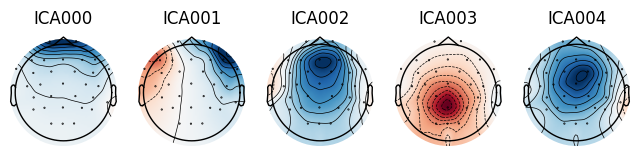

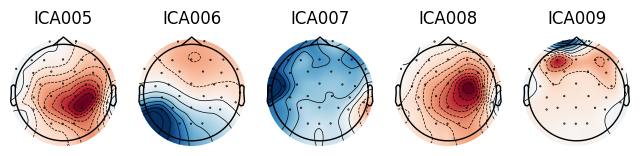

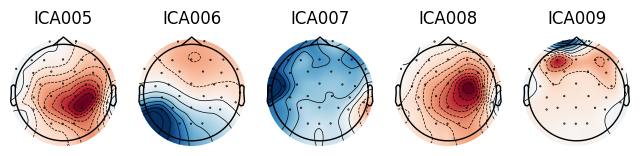

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(8, 8))
ica.plot_components(picks=range(5), axes=axes,
                    extrapolate="head", image_interp="cubic", show=True, cmap="RdBu", contours=10);

fig, axes = plt.subplots(1, 5, figsize=(8, 8))
ica.plot_components(picks=range(5, 10), axes=axes,
                    extrapolate="head", image_interp="cubic", show=True, cmap="RdBu", contours=10);

fig, axes = plt.subplots(1, 5, figsize=(8, 8))
ica.plot_components(picks=range(5, 10), axes=axes,
                    extrapolate="head", image_interp="cubic", show=True, cmap="RdBu", contours=10);

### Read Epochs obejct from EEGLA

```
epochs = mne.read_epochs_eeglab(f"{DIRECTORY}/{EPOCHS_FILE_PATH}")
epochs = epochs.drop_channels(["HEOG", "VEOG"], on_missing="raise")
assert len(epochs.ch_names) == len(raw_for_ica.ch_names)

epochs_sources = ica.get_sources(epochs)
sources = epochs_sources.get_data()

mne.export.export_epochs(f"{DIRECTORY}/SUBJ020/subj020_sources-reconstructed.set", epochs_sources,
                         fmt="eeglab", overwrite=True, verbose=True)
```

Effective window size : 2.000 (s)
Not setting metadata
1645 matching events found
No baseline correction applied
0 projection items activated


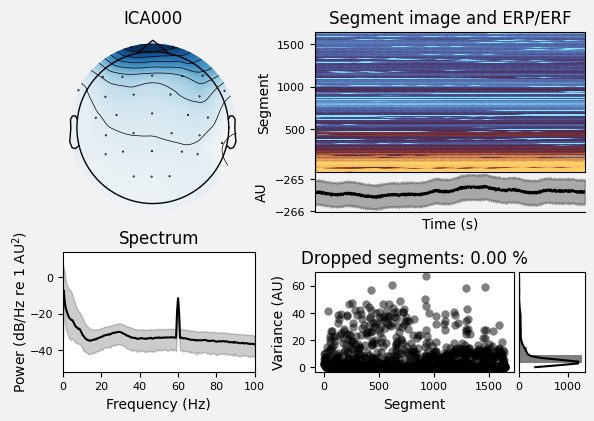

In [10]:
topomap_args = {"cmap": "RdBu", "image_interp": "cubic", "contours": 10}
image_args = {"vmin": lambda X: np.percentile(X, 5),
              "vmax": lambda X: np.percentile(X, 95),
              "cmap": "managua"}
psd_args = {"fmax": 100, "method": "welch"}

COMPONENT_INDEX = 0
ica.plot_properties(raw_usual, picks =[COMPONENT_INDEX],
                    figsize=(6, 4),
                    verbose="INFO",
                    topomap_args=topomap_args,
                    image_args=image_args,
                    psd_args=psd_args,
                    log_scale=False,
                    estimate="power"); # for psd

### Apply ICA-cleaning on continuous data (re-referenced)

In [20]:
EXCLUDE_INDICES = [0] # can be plural
ica.exclude = EXCLUDE_INDICES
raw_cleaned = raw_usual.copy()
ica.apply(raw_cleaned);

Applying ICA to Raw instance
    Transforming to ICA space (31 components)
    Zeroing out 1 ICA component
    Projecting back using 31 PCA components


### Detrend and bandpass filter (IIR Butterworth, Order 2, 0.1 - 30 Hz)

In [22]:
# Detrend data (remove DC offset)
raw_cleaned_copy = raw_cleaned.copy()
data_cleaned = raw_cleaned.copy().get_data()
data_cleaned_detrended = detrend(data_cleaned, axis=-1, type="constant")
raw_cleaned = mne.io.RawArray(data=data_cleaned_detrended, info=info)
_ = raw_cleaned.set_annotations(raw_cleaned_copy.annotations)

# bandpass filter
raw_cleaned_filt = raw_cleaned.copy().filter(l_freq=0.1, h_freq=30, method="iir", iir_params=bandpass_params_usual, verbose=False)


Creating RawArray with float64 data, n_channels=31, n_times=3290100
    Range : 0 ... 3290099 =      0.000 ...  3290.099 secs
Ready.


In [24]:
mne.export.export_raw(f"{DIRECTORY}/SUBJ020/subj020_raw_ICAed.set", raw_cleaned_filt,
                         fmt="eeglab", overwrite=True, verbose=True)

Overwriting existing file.


### Automatically identifying potential eye blink ICs

In [88]:
# Reset ica.exclude
ica.exclude = []
# find which ICs match the EOG pattern
eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica.copy(),
                                            ch_name=["Fp1", "Fp2"],
                                            threshold=0.9,
                                            measure="correlation",
                                            l_freq=None, h_freq=None, # raw_for_ica already filtered; don't filter it here again
                                            reject_by_annotation=True,
                                            verbose=True)
print(f"\n >> Most likely blink IC(s): {[int(i) for i in eog_indices]}")
for i, ch in enumerate(["Fp1", "Fp2"]):
    print(f"      Correlation with {ch}: {eog_scores[i][*eog_indices]}")

ica.exclude = eog_indices

Using EOG channels: Fp1, Fp2
Omitting 948199 of 3290100 (28.82%) samples, retaining 2341901 (71.18%) samples.
Omitting 948199 of 3290100 (28.82%) samples, retaining 2341901 (71.18%) samples.
Omitting 948199 of 3290100 (28.82%) samples, retaining 2341901 (71.18%) samples.
Omitting 948199 of 3290100 (28.82%) samples, retaining 2341901 (71.18%) samples.

 >> Most likely blink IC(s): [0]
      Correlation with Fp1: 0.9667462971291537
      Correlation with Fp2: 0.9781358137260259


In [ ]:
ELIST_INPATH = "/Users/jowanglin/Downloads/elist.txt"

def parse_elist(elist_inpath: str, drop_boundaries: bool=False):
    with open(elist_inpath) as f:
        lines = f.readlines()
    for idx, line in enumerate(lines):
        if line.startswith("# item"):
            break
    lines = lines[idx:]
    elist_outpath = elist_inpath.split(".")[0] + "_reformatted.txt"
    with open(elist_outpath, "w") as f:
        f.writelines(lines)

    elist_df = pd.read_csv(elist_outpath, sep="\t")
    elist_df = elist_df.iloc[1:].reset_index(drop=True)
    elist_df = elist_df.rename(mapper=lambda s: s.replace(" ", ""), axis=1)
    elist_df = elist_df.rename(columns={"b_flags": "b_flags-a_flags",
                                        "a_flags": "enable",
                                        "enable": "bin",
                                        "bin": "drop"})
    elist_df = elist_df.drop(columns="drop")
    if drop_boundaries:
        elist_df = elist_df.loc[~ elist_df["label"].astype(str).str.contains("boundary",
                                                                 case=False,
                                                                 na=False,
                                                                 regex=False)].reset_index(drop=True)
    return elist_df

elist_df = parse_elist(ELIST_INPATH, drop_boundaries=True)
display(elist_df)

,#item,bepoch,ecode,label,onset,diff,dura,b_flags-a_flags,enable,bin
0,2,0.0,254.0,S254,34.6250,34625.00,1.0,00000000 00000000,1.0,[ ]
1,3,0.0,1.0,S1,35.2090,584.00,1.0,00000000 00000000,1.0,[ ]
2,4,0.0,254.0,S254,45.8160,10607.00,1.0,00000000 00000000,1.0,[ ]
3,5,0.0,251.0,S251,46.3370,521.00,1.0,00000000 00000000,1.0,[ ]
4,6,0.0,105.0,S105,47.3540,1017.00,1.0,00000000 00000000,1.0,[ ]
...,...,...,...,...,...,...,...,...,...,...
3222,3224,0.0,253.0,S253,3239.5491,1802.00,1.0,00000000 00000000,1.0,[ ]
3223,3225,0.0,1.0,S1,3241.0640,1514.89,1.0,00000000 00000000,1.0,[ ]
3224,3226,0.0,254.0,S254,3242.7959,1731.93,1.0,00000000 00000000,1.0,[ ]
3225,3227,0.0,1.0,S1,3244.3149,1519.04,1.0,00000000 00000000,1.0,[ ]


### SSP
Filter settings:
- Bandpass 0.1 - 30 Hz, IIR Butterworth
(same as normal pre-processing)

In [71]:
epochs = mne.read_epochs_eeglab(f"{DIRECTORY}/{EPOCHS_FILE_PATH}")
# epochs = epochs.drop_channels(["HEOG", "VEOG"], on_missing="raise") # <- no need to drop
                                                                      # as HEOG & VEOG won't get projections applied to them
                                                                      # probably better to keep them for before SSP bs after SSP comparison in EEGLAB

Extracting parameters from /Users/jowanglin/Word-Position-Effect_BLP-lab/Preprocessing/ica-data/SUBJ020/subj020_chan_rr_elist_bin_epbaseline_AD_BPdot1-30.set...
Not setting metadata
1859 matching events found


/var/folders/n3/nqqvqq1n0jx25dfd3nyxjxmh0000gn/T/ipykernel_62275/2571466582.py:1: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.read_epochs_eeglab(f"{DIRECTORY}/{EPOCHS_FILE_PATH}")


No baseline correction applied
0 projection items activated
Ready.


In [52]:
ssp_bandpass_params = mne.filter.create_filter(
    data=raw.copy().get_data(),
    sfreq=raw.info["sfreq"],
    l_freq=0.1, h_freq=30,  
    method="iir",
    iir_params={"order": 2, "ftype": "butter"},
    verbose=True
)
raw_for_ssp = raw.copy().filter(l_freq=0.1, h_freq=30, method="iir", iir_params=ssp_bandpass_params, verbose=False)

Setting up band-pass filter from 0.1 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoffs at 0.10, 30.00 Hz: -6.02, -6.02 dB



Shape of eog_epochs = (869, 31, 401)
No projector specified for this dataset. Please consider the method self.add_proj.


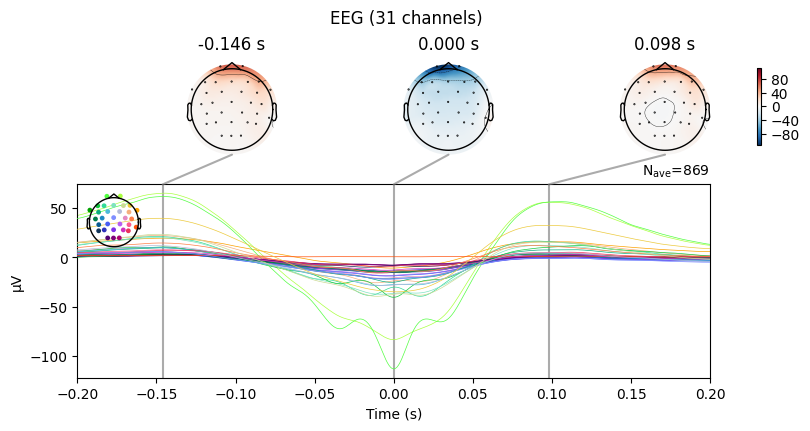

In [65]:
eog_epochs = create_eog_epochs(raw_for_ssp.copy(),
                               event_id=999,
                               l_freq=None, h_freq=None, 
                               ch_name = ["Fp1", "Fp2"],
                               picks = "all",
                               tmin = -0.2,
                               tmax = 0.2,
                               baseline = None,
                               decim = 1,     # don't downsample
                               flat = None,
                               reject_by_annotation=False,
                               thresh=None,  # use default
                               preload = True, 
                               verbose = False)
eog_evoked = eog_epochs.average()
print(f"Shape of eog_epochs = {eog_epochs.get_data().shape}")

eog_evoked.plot_joint();

In [66]:
eog_projs, eog_events, drop_log = compute_proj_eog(
             raw_for_ssp.copy(),
             copy=True,
             ch_name = ["Fp1", "Fp2"],
             tmin = -0.2,
             tmax = 0.2,
             event_id=999,
             l_freq=None, h_freq=None,
             eog_l_freq=None, eog_h_freq=None, 
             tstart=0.0,
             filter_method="iir",
             iir_params = bandpass_params,
             return_drop_log=True,
             n_eeg=3,
             reject=None,
             average=True,    # If average=True, SSP is computed after eog_epochs.average(), i.e., getting eog_evoked
                              # I think average=True makes more sense
             n_jobs=-1,
             avg_ref=False,   # don't add average reference as a projector
             verbose=False);
assert np.array_equal(eog_epochs.events, eog_events)
print(f"  >> compute_proj_eog also found {len(eog_events)} EOG events.")
display(eog_projs)

  >> compute_proj_eog also found 869 EOG events.


[<Projection | EOG-eeg--0.200-0.200-PCA-01, active : False, n_channels : 31, exp. var : 94.07%>,
 <Projection | EOG-eeg--0.200-0.200-PCA-02, active : False, n_channels : 31, exp. var : 5.38%>,
 <Projection | EOG-eeg--0.200-0.200-PCA-03, active : False, n_channels : 31, exp. var : 0.39%>]

In [67]:
proj_vecs = np.array([eog_projs[i]["data"]["data"] for i in range(len(eog_projs))]).squeeze(axis=1).T
print(f"Shape of projector vectors (I stacked them): {proj_vecs.shape}")
print(f"Rank of stacked projector vectors: {np.linalg.matrix_rank(proj_vecs, tol=1e-2)}")

eog_data = eog_evoked.copy().get_data().T
# MNE probably does something like this if average=False in compute_proj_eog
# eog_data = np.hstack(eog_epochs.copy().get_data()).T  
pca = PCA(n_components=3, whiten=True, random_state=42) 
pca.fit(eog_data)
eigen_vecs, explained_var = pca.components_, pca.explained_variance_

directional_alignment = [abs(v1.T @ v2) for v1, v2 in zip(eigen_vecs, proj_vecs.T)]
print(f"\n >> Directional alignment (absolute cosine similarity) vs manually PCAed directions:\n {directional_alignment}")

Shape of projector vectors (I stacked them): (31, 3)
Rank of stacked projector vectors: 3

 >> Directional alignment (absolute cosine similarity) vs manually PCAed directions:
 [np.float64(0.9991079278071348), np.float64(0.17486696036504262), np.float64(0.029805385769419213)]


In [68]:
mne.export.export_epochs(f"{DIRECTORY}/SUBJ020/eog_epochs.set", eog_epochs,
                      fmt="eeglab", overwrite=True, verbose=True)

Overwriting existing file.


/Users/jowanglin/Word-Position-Effect_BLP-lab/wordpos/lib/python3.11/site-packages/eeglabio/epochs.py:137 EEGLABIO: WARNING: Some or all annotations have invalid onsets, discarded for export.


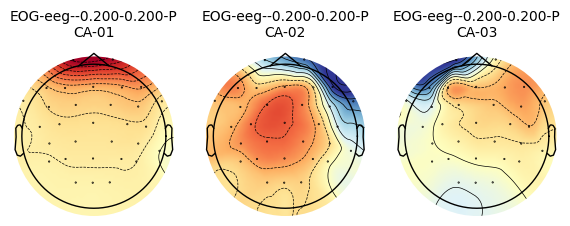

3 projection items deactivated


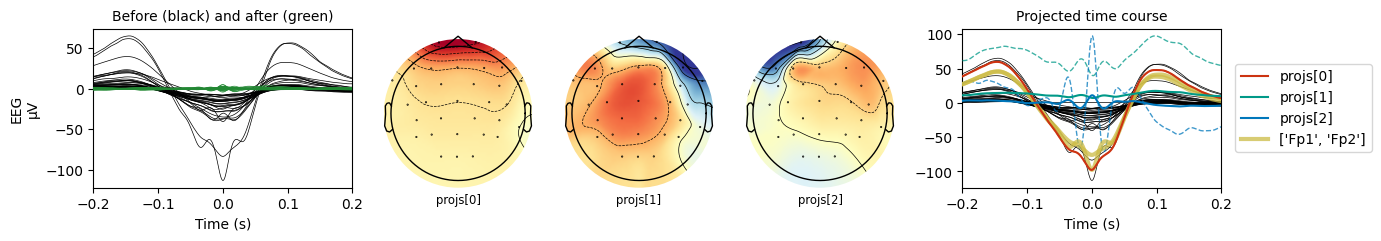

In [69]:
_, axes = plt.subplots(1, 3, figsize=(7, 7))
mne.viz.plot_projs_topomap(eog_projs, info=raw.info, axes=axes,
                    extrapolate="head", image_interp="cubic", cmap="RdYlBu", contours=10, show=True)

mne.viz.plot_projs_joint(eog_projs, eog_evoked, topomap_kwargs={"cmap": "RdYlBu"}, picks_trace=["Fp1", "Fp2"]);

In [72]:
PROJS_TO_ADD = [0]  # can be plural
epochs.add_proj([eog_projs[i] for i in PROJS_TO_ADD])
epochs.apply_proj()

mne.export.export_epochs(f"{DIRECTORY}/SUBJ020/subj020_SSPed.set", epochs,
                      fmt="eeglab", overwrite=True, verbose=True)

1 projection items deactivated
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Overwriting existing file.


In [73]:
display(epochs.info)

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, CP5, CP1, Pz, P3, P7, ...
 chs: 33 EEG
 custom_ref_applied: False
 dig: 33 items (33 EEG)
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: unspecified
 nchan: 33
 projs: EOG-eeg--0.200-0.200-PCA-01: on
 sfreq: 1000.0 Hz
>